In [1]:
from ppopt.mplp_program import MPLP_Program
from ppopt.mpmodel import MPModeler
from ppopt.mp_solvers.solve_mpqp import solve_mpqp, mpqp_algorithm
from typing import List, Callable, Union
from collections import defaultdict
from numpy.polynomial.legendre import leggauss
from scipy.optimize import linprog
import itertools as itools
from sympy.logic.boolalg import BooleanTrue, BooleanFalse
import numpy as np
import chaospy as cp
import pickle
import time
import warnings
from concurrent.futures import as_completed, ThreadPoolExecutor
from functools import partial
import os
from tqdm.auto import tqdm
from scipy.stats import qmc
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import gurobipy as gp
from gurobipy import GRB
from gurobipy import nlfunc
import matplotlib.pyplot as plt

## Smolyak quadrature

In [2]:
def theta_interval_at_point(solution, theta_vector: np.ndarray, max_idx: int = 0, min_idx: int = 1) -> tuple:
    """Given the parametric solution for theta_k and the current 'state' vector (theta_prev + d),
        return the scalar lower and upper bound [t_min, t_max] for this theta_k.

    Args:
        solution (_type_): _description_
        t_vector (np.ndarray): _description_
        max_idx (int, optional): _description_. Defaults to 0.
        min_idx (int, optional): _description_. Defaults to 1.

    Returns:
        tuple: _description_
    """

    theta_vector_aug = np.append(theta_vector, 1).reshape(-1, 1)

    if isinstance(solution, list):
        theta_min = solution[0]
        theta_max = solution[1]
        return float(theta_min), float(theta_max)
    
    try:
        region = solution.get_region(theta_vector.reshape(-1, 1))
        coefficients = np.concatenate([region.A, region.b], axis=1)[:2, :]
        max_coefficients = coefficients[max_idx]
        min_coefficients = coefficients[min_idx]
        # theta_max = float(max_coefficients @ theta_vector_aug)
        # theta_min = float(min_coefficients @ theta_vector_aug)
        theta_max = (max_coefficients @ theta_vector_aug).item()
        theta_min = (min_coefficients @ theta_vector_aug).item()
        return theta_min, theta_max
    except:
        raise ValueError(
        "The provided theta_vector is not inside any critical region of the solution.")

def map_u_to_theta_and_jacobian(solutions, u, dvector):
    """
    Given stage-aligned parametric solutions for theta_k and the current
    disturbance vector d, return the theta vector and the Jacobian.

    Parameters
    ----------
    solutions : list
        Stage-aligned list. Each entry is either:
        - a valid parametric solution object for stage k, or
        - None for an empty / unusable stage.
    u : np.ndarray
        1D array of canonical coordinates.
    dvector : np.ndarray
        Current disturbance/design vector.

    Returns
    -------
    theta_values : np.ndarray
        Stage-aligned theta vector, same length as solutions.
    jacobian : float
    """
    theta_values = []
    jacobian = 1.0

    for k, sol in enumerate(solutions):
        if sol is None:
            theta_k = 0.0
            theta_values.append(theta_k)
            continue

        if isinstance(dvector, np.ndarray):
            thetavector = np.block([np.array(theta_values, dtype=float), dvector])
        else:
            thetavector = np.array(theta_values, dtype=float)

        thetamin, thetamax = theta_interval_at_point(sol, thetavector)
        length = thetamax - thetamin

        theta_k = 0.5 * length * u[k] + 0.5 * (thetamax + thetamin)
        theta_values.append(theta_k)

        jacobian *= 0.5 * length

    return np.array(theta_values, dtype=float), jacobian


def calculate_stocflexibility_smolyak(solutions: List, level: int, joint_func: Callable[[List[float]], float], d_vector: np.ndarray = None, rule: str = "gaussian", ns_u = None, ws_u = None) -> float:
    """Compute stochastic flexibility using a Smolyak sparse grid in canonical  u-space

    Args:
        solutions (List): list of solutions for each theta dimension (same structure as in calculate_stocflexibility)
        level (int): Smolyak level (1,2,3,...) controls accuracy & number of points
        joint_func (Callable[[List[float]], float]): callable f(theta_list) -> scalar
        d_vector (np.ndarray, optional):design vector (np.ndarray). Defaults to None.
        rule (str, optional): 1D quadrature rule passed to chaospy (e.g. "gaussian"). Defaults to "gaussian".

    Returns:
        float: _description_
    """

    n_theta = len(solutions)
    
    if ns_u is None or ws_u is None:
        ns_u, ws_u = smolyak_nodes_weights(
            n_theta=n_theta,
            level=level,
            rule=rule,
            growth=True,
        )

    start = time.time()
    stochastic_flexibility = 0.0

    for i in range(ns_u.shape[0]):
        u_vector = ns_u[i, :]
        theta_vector, jacobian = map_u_to_theta_and_jacobian(
            solutions, u_vector, d_vector)
        func_value = joint_func(theta_vector)
        stochastic_flexibility += func_value * jacobian * ws_u[i]

    end = time.time()
    print(
        f"Smolyak stochastic flexibility computed in {end - start:.4f} seconds.")
    return stochastic_flexibility

## Gaussian Legendre quadrature

In [3]:
def gauss_legendre_between_bounds(expr_coeffs: np.ndarray, n_gl: int, max_idx: int = 0, min_idx: int = 1):
    """
    Generate n Gauss–Legendre quadrature points and weights between min and max bounds
    defined by two linear expressions.

    Parameters:
        expr_coeffs (np.ndarray): 2xD array. Row 0 = max point co`efficients, Row 1 = min.
        n (int): Number of quadrature points.

    Returns:
        points (np.ndarray): (n, D) array of quadrature points.
        weights (np.ndarray): (n,) array of weights.
    """
    if expr_coeffs.shape[0] != 2:
        raise ValueError("expr_coeffs must have two rows")

    max_coeffs = expr_coeffs[max_idx]
    min_coeffs = expr_coeffs[min_idx]

    # Get Gauss–Legendre points and weights on [-1, 1]
    nodes, weights = leggauss(n_gl)
    weights = weights.reshape(-1, 1)

    # Affine transformation to domain [min_coeffs, max_coeffs]
    points = 0.5 * (np.outer((nodes + 1), max_coeffs) +
                    np.outer((1 - nodes), min_coeffs))

    # Adjust weights to match new domain
    weights = 0.5 * weights@(max_coeffs - min_coeffs).reshape(1, -1)

    return points, weights


def get_quadrature_points(solution, nq: int, t_vector: np.ndarray):
    # Augment t_vector once
    t_vector_aug = np.append(t_vector, 1).reshape(-1, 1)

    if isinstance(solution, list):
        qpoints, qweights = np.polynomial.legendre.leggauss(nq)
        min, max = solution[0], solution[1]
        qps_mapped = 0.5*(max*(1+qpoints) + min*(1-qpoints))
        qws_mapped = 0.5*(max-min)*qweights
        # print(max, min, qps_mapped, qws_mapped)
        return max, min, qps_mapped, qws_mapped
    
    try:
        region = solution.get_region(t_vector.reshape(-1, 1))
        coeffs = np.concatenate([region.A, region.b], axis=1)[:2, :]
        qpoints, qweights = gauss_legendre_between_bounds(
            expr_coeffs=coeffs, n_gl=nq)
        return coeffs[0] @ t_vector_aug, coeffs[1] @ t_vector_aug, qpoints @ t_vector_aug, qweights @ t_vector_aug
    except:
        raise ValueError("No region found that contains the given t_vector.")


def calculate_stocflexibility(
    sols,
    nq: Union[int, list],
    joint_func,
    d_vector: np.ndarray = None,
    verbose: bool = True,
):
    # Validate nq if it's a list
    if isinstance(nq, list):
        if len(nq) != len(sols):
            raise ValueError(
                "If nq is a list, it must have the same length as sols")

    start_time = time.perf_counter()

    def recurse(level: int, theta_prev: list, weight_prev: float) -> float:
        if level == len(sols):
            return weight_prev * joint_func(theta_prev)

        nql = nq[level] if isinstance(nq, list) else nq

        t_vector = (
            np.block([np.array(theta_prev), d_vector])
            if isinstance(d_vector, np.ndarray)
            else np.array(theta_prev)
        )

        _, _, t_points, t_weights = get_quadrature_points(
            solution=sols[level],
            nq=nql,
            t_vector=t_vector,
        )

        t_points = t_points.flatten()
        t_weights = t_weights.flatten()

        return sum(
            recurse(level + 1, theta_prev + [v], weight_prev * w)
            for v, w in zip(t_points, t_weights)
        )

    stflex = recurse(level=0, theta_prev=[], weight_prev=1.0)

    end_time = time.perf_counter()

    if verbose:
        print(f"Gaussian Legendre Stochastic Flexibility Elapsed time: {end_time - start_time:.4f} s"
              )

    return stflex

In [4]:
def mpformulate_theta_bounds(flex_sol, num_theta: int, theta_bounds: list, num_design: int = 0, design_bounds: list = None, psi_idx: int = 0, theta_m: int = 0):
    A0, b0, F0 = np.empty((len(flex_sol), num_theta)), np.empty(
        (len(flex_sol), 1)), np.empty((len(flex_sol), num_design))
    num_cr = len(flex_sol.critical_regions)
    for i, region in enumerate(flex_sol.critical_regions):
        A0[i] = region.A[psi_idx, :num_theta]
        b0[i] = -region.b[psi_idx]
        F0[i] = -region.A[psi_idx, num_theta:num_theta+num_design]
    # print(f'num_cr:{num_cr}')
    # print(f'num_theta:{num_theta}')
    # print(f'num_design:{num_design}')
    # print(f"A0: {A0}")
    # print(f"b0: {b0}")
    # print(f"F0: {F0}")

    c = np.hstack([np.array([-1, 1]).reshape(1, -1),
                  np.zeros((1, 2 * (num_theta - 1 - theta_m)))]).reshape(-1, 1)
    # print(f'c:{c}')
    # print(f'c.shape: {c.shape}')

    row1_block = np.hstack([block for i in range(theta_m, num_theta)
                           for block in (A0[:, [i]], np.zeros((num_cr, 1)))])
    row2_block = np.hstack([block for i in range(theta_m, num_theta)
                           for block in (np.zeros((num_cr, 1)), A0[:, [i]])])
    bound_row = np.hstack([np.array([-1, 1]).reshape(1, -1),
                          np.zeros((1, 2 * (num_theta - 1 - theta_m)))])
    A = np.vstack([row1_block, row2_block, bound_row, -
                  np.eye(2*(num_theta-theta_m)), np.eye(2*(num_theta-theta_m))])
    # print(f'A: {A}')
    # print(f'A.shape: {A.shape}')

    x_lb = np.array([val for i in range(theta_m, len(theta_bounds))
                    for val in [theta_bounds[i][0]] * 2])
    x_ub = np.array([val for i in range(theta_m, len(theta_bounds))
                    for val in [theta_bounds[i][1]] * 2])
    b = np.vstack([b0, b0, np.zeros((1, 1)), -
                  x_lb.reshape(-1, 1), x_ub.reshape(-1, 1)])
    # print(f'b: {b}')
    # print(f'b.shape: {b.shape}')

    if F0.size == 0 and theta_m == 0:
        # print('here')
        return A, b, c, np.array([]), np.array([]), np.array([]), np.array([])

    F = np.vstack([F0, F0, np.zeros((1, num_design)), np.zeros(
        (4*(num_theta-theta_m), num_design))]) if num_design > 0 else np.vstack([F0, F0])
    # print(f'F:{F}')
    # print(f'F.shape: {F.shape}')
    if theta_m > 0:
        F_lltheta = np.hstack([A0[:, [i]] for i in range(theta_m)])
        # print(f'F_lltheta: {F_lltheta}')
        # print(f'F_lltheta.shape: {F_lltheta.shape}')
        F = np.hstack([np.vstack([-F_lltheta, -F_lltheta, np.zeros((1, len(range(theta_m)))), np.zeros((4*(num_theta-theta_m), theta_m))]), F]
                      ) if F.size > 0 else np.vstack([-F_lltheta, -F_lltheta, np.zeros((1, len(range(theta_m)))), np.zeros((4*(num_theta-theta_m), theta_m))])
    # print(f'F:{F}')
    # print(f'F.shape: {F.shape}')

    H = np.zeros((2*(num_theta-theta_m), theta_m+num_design))
    # print(f'H:{H}')
    # print(f'H.shape: {H.shape}')

    A_t = np.vstack([-np.eye(theta_m+num_design), np.eye(theta_m+num_design)])
    # print(f'A_t:{A_t}')
    # print(f'A_t.shape: {A_t.shape}')

    theta_lb = np.array([-theta_bounds[i][0] for i in range(theta_m)] + ([-j[0] for j in design_bounds] if isinstance(design_bounds, list)
                                                                         else [])).reshape(-1, 1)
    theta_ub = np.array([theta_bounds[i][1] for i in range(theta_m)] + ([j[1] for j in design_bounds] if isinstance(design_bounds, list)
                                                                        else [])).reshape(-1, 1)

    b_t = np.vstack([theta_lb, theta_ub])
    # print(f'b_t:{b_t}')
    # print(f'b_t.shape: {b_t.shape}')

    return A, b, c, H, A_t, b_t, F

In [5]:
def get_theta_bounds(flex_sol, numt, tbounds, numd: int = 0, dbounds: list = None, mp_algo: mpqp_algorithm = mpqp_algorithm.combinatorial):
    theta_bound_dict = defaultdict(dict)
    prob_dict = defaultdict(dict)

    for i in range(numt):
        A, b, c, H, A_t, b_t, F = mpformulate_theta_bounds(
            flex_sol=flex_sol, num_theta=numt, num_design=numd, theta_bounds=tbounds, design_bounds=dbounds, theta_m=i)
        # print(f'A.shape:{A.shape}')
        # print(f'b.shape: {b.shape}')
        # print(f'F.shape: {F.shape}')
        if F.size != 0:
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("error", category=UserWarning, message="The chebychev ball has either a radius of zero, or the problem is not feasible!")
                    prob = MPLP_Program(A=A, b=b, c=c, H=H, A_t=A_t, b_t=b_t, F=F)

                prob.process_constraints()
                solution = solve_mpqp(problem=prob, algorithm=mp_algo)

                prob_dict[f"t{i}"] = prob
                theta_bound_dict[f"t{i}"] = solution

            except UserWarning as w:
                # MPLP infeasible / degenerate
                print(f"[theta {i}] MPLP infeasible / zero Chebyshev ball: {w}")
                prob_dict[f"t{i}"] = None
                theta_bound_dict[f"t{i}"] = None

        else:
            # LP fallback branch via scipy.optimize.linprog
            linres = linprog(c=c, A_ub=A, b_ub=b)

            if not linres.success:
                print(f"[theta {i}] linprog failed: status={linres.status}, "f"message={linres.message}")
                prob_dict[f"t{i}"] = linres
                theta_bound_dict[f"t{i}"] = None
            else:
                prob_dict[f"t{i}"] = linres
                theta_bound_dict[f"t{i}"] = [linres.x[1], linres.x[0]]

        print(f"Finished solving for theta{i+1}")

    probs = [p for _, p in prob_dict.items()]
    sols = [sol for _, sol in theta_bound_dict.items()]
    return probs, sols

In [6]:
def get_bounds_regions(sols: List, min_idx: int = 1, max_idx: int = 0):
    t_bounds_list = []
    t_regions_list = []

    for theta_sol in sols:    
        # if theta_sol is None:
        #     t_bounds_list.append(np.array([]))  # placeholder, will be ignored
        #     t_regions_list.append(np.array([np.zeros((1, 3))], dtype=float))
        #     continue
        # 
        # if not getattr(theta_sol, "critical_regions", None):
        #     tmin, tmax = float(theta_sol[0]), float(theta_sol[1])
        #     
        #     min_row = [0.0, 0.0, tmin]   # placeholder structure
        #     max_row = [0.0, 0.0, tmax]
        #     
        #     t_bounds_list.append(np.array([[min_row, max_row]], dtype=float))
        #     t_regions_list.append(np.array([np.zeros((1, 3))], dtype=float))
        #     
        #     continue
        
        if theta_sol is None:
            t_bounds_list.append(None)
            t_regions_list.append(None)
            continue
        
        if not getattr(theta_sol, "critical_regions", None):
            t_bounds_list.append(None)
            t_regions_list.append(None)
            continue
        
        min_max_list = []
        region_list = []

        for cr in theta_sol.critical_regions:
            # Store bounds
            Ab = np.concatenate([cr.A, cr.b], axis=1)[:2]
            min_max_list.append([Ab[min_idx].tolist(), Ab[max_idx].tolist()])

            # Store region constraints
            Ef = np.concatenate([cr.E, -cr.f], axis=1)
            region_array = np.array([row.tolist() for row in Ef], dtype=float)
            region_list.append(region_array)

        # Append per-theta data
        t_bounds_list.append(np.array(min_max_list))
        # <-- each region is a 2D array
        t_regions_list.append(np.array(region_list, dtype=object))

    return t_bounds_list, t_regions_list


def generate_region_combos(region_sizes, n_gl):
    """Generate region index combinations based on critical region structure."""
    n_theta = len(region_sizes)
    region_combo_shape = []
    for k in range(n_theta):
        n_paths = int(np.prod(n_gl[:k])) if k > 0 else 1
        region_combo_shape.extend([range(region_sizes[k])] * n_paths)
    return list(itools.product(*region_combo_shape))


def affine_expr(coeffs, symbols):
    return sum(c * s for c, s in zip(coeffs[:-1], symbols)) + coeffs[-1]


def normalized_lhs(ineq):
    return ineq.lhs.expand() if hasattr(ineq, 'lhs') else None

In [7]:
def _prepare_state_data(state, tbounds, dbounds, *, solve_algo, theta_algo, log=False):
    """
    Build and solve the flexibility problem for one state, then return only valid theta-related data.

    Returns
    -------
    dict with keys:
        state
        flex_sol
        sol_list
        t_bounds_list
        t_regions_list
        filtered_solutions
        filtered_theta_bounds
        filtered_theta_regions
    or None if no valid theta regions exist.
    """
    state_model = create_flexibility_model(y_list=state, tbounds=tbounds, dbounds=dbounds)
    state_prob = state_model.formulate_problem()
    state_prob.process_constraints()

    flex_sol = solve_mpqp(problem=state_prob, algorithm=solve_algo)

    if log:
        print(f"Number of critical regions in for flexibility function for state {state}: {len(flex_sol.critical_regions)}")

    _, sol_list = get_theta_bounds(flex_sol=flex_sol, numt=nt, numd=nd, tbounds=t_bounds, dbounds=dbounds, mp_algo=theta_algo)

    t_bounds_list, t_regions_list = get_bounds_regions(sols=sol_list)
    
    filtered_solutions      = []
    filtered_theta_bounds   = []
    filtered_theta_regions  = []
    
    for k, (sol, tb, tr) in enumerate(zip(sol_list, t_bounds_list, t_regions_list)):
        if sol is None or tb is None or tr is None:
            # mark as empty stage but preserve position
            filtered_solutions.append(None)
            filtered_theta_bounds.append(None)
            filtered_theta_regions.append(None)
        else:
            filtered_solutions.append(sol)
            filtered_theta_bounds.append(tb)
            filtered_theta_regions.append(tr)

    return {
        "state": state,
        "flex_sol": flex_sol,
        "sol_list": sol_list,
        "theta_bounds_list": t_bounds_list,
        "theta_regions_list": t_regions_list,
        "filtered_solutions": filtered_solutions,
        "filtered_theta_bounds": filtered_theta_bounds,
        "filtered_theta_regions": filtered_theta_regions,
    }

In [8]:
def _safe_sf_call(func, state, label, **kwargs):
    """
    Safely evaluate a stochastic flexibility routine for one state.

    Returns
    -------
    float or None
        None means: skip this state's contribution.
    """
    try:
        return func(**kwargs)

    except ValueError as e:
        msg = str(e)

        known_skip_markers = (
            "not inside any critical region",
            "No region found that contains the given t_vector",
            "No solution available for this stage",
            "no valid theta regions",
            "no valid stages",
        )

        if any(marker in msg for marker in known_skip_markers):
            print(f"Skipping {label} SF for state {state}: {e}")
            return None

        raise

In [9]:
def calculate_gl_esf(y_d: dict, prepared_data_by_state: dict, d_v, n_q: int):
    """
    Gaussian-Legendre ESF using stage-aligned prepared data.
    Assumes calculate_stocflexibility() now handles None entries in sols.
    """
    gl_esf = 0.0
    esf_by_state = {}

    for state, prob in y_d.items():
        try:
            data = prepared_data_by_state.get(state)

            if data is None:
                print(f"No valid theta regions for state {state}; skipping state")
                continue

            sols = data.get("filtered_solutions", None)

            if sols is None or len(sols) == 0:
                print(f"No filtered solutions for state {state}; skipping state")
                continue

            if not any(sol is not None for sol in sols):
                print(f"All filtered solutions are None for state {state}; skipping state")
                continue

            sf_idx_gaussian = _safe_sf_call(
                calculate_stocflexibility,
                state=state,
                label="Gaussian",
                sols=sols,
                nq=n_q,
                joint_func=joint_pdf,
                d_vector=d_v,
            )

            if sf_idx_gaussian is not None:
                esf_by_state[state] = sf_idx_gaussian
                gl_esf += sf_idx_gaussian * prob

        except ValueError as e:
            print(f"Skipping state {state} due to ValueError: {e}")
            continue

        print(f"Finished for state {state}.")

    return gl_esf, esf_by_state

In [10]:
def calculate_sm_esf(y_d: dict, prepared_data_by_s: dict, d_v, s_level: int, ns_u=None, ws_u=None):
    """
    Smolyak ESF using stage-aligned prepared data.
    Assumes map_u_to_theta_and_jacobian() now handles None entries in solutions.
    """
    sm_esf = 0.0
    esf_by_state = {}

    for s, p in y_d.items():
        try:
            data = prepared_data_by_s.get(s)

            if data is None:
                print(f"No valid theta regions for state {s}; skipping state")
                continue

            sols = data.get("filtered_solutions", None)

            if sols is None or len(sols) == 0:
                print(f"No filtered solutions for state {s}; skipping state")
                continue

            if not any(sol is not None for sol in sols):
                print(f"All filtered solutions are None for state {s}; skipping state")
                continue

            sf_idx_smolyak = _safe_sf_call(
                calculate_stocflexibility_smolyak,
                state=s,
                label="Smolyak",
                solutions=sols,
                level=s_level,
                joint_func=joint_pdf,
                d_vector=d_v,
                ns_u = ns_u,
                ws_u = ws_u,
            )

            if sf_idx_smolyak is not None:
                esf_by_state[s] = sf_idx_smolyak
                sm_esf += sf_idx_smolyak * p

        except ValueError as e:
            print(f"Skipping state {s} due to ValueError: {e}")
            continue

        print(f"Finished for state {s}.")

    return sm_esf, esf_by_state

## Gaussian Legendre SF Expressions

In [11]:
def compute_sf_exprs_regions(
    t_bounds_list,
    t_regions_list,
    joint_pdf_expr,
    d_syms,
    n_gl_list,
    theta_syms
):
    n_theta = len(theta_syms)
    quad_data = [np.polynomial.legendre.leggauss(n) for n in n_gl_list]
    region_sizes = [bounds.shape[0] for bounds in t_bounds_list]
    region_combos = generate_region_combos(region_sizes, n_gl_list)

    sf_exprs = []
    sf_regions = []

    for region_combo in region_combos:
        combo_ptr = 0
        # Initialize integration paths: (theta_vals, weight, scale, constraints)
        paths = [([], 1, 1, [])]

        for level in range(n_theta):
            xi, wi = quad_data[level]
            new_paths = []

            for theta_vals, weight, scale, constraints in paths:
                region_idx = region_combo[combo_ptr]
                combo_ptr += 1

                bound_inputs = theta_vals + list(d_syms)
                bounds = t_bounds_list[level][region_idx]
                t_min = affine_expr(bounds[0], bound_inputs)
                t_max = affine_expr(bounds[1], bound_inputs)

                # Get level-specific region constraints
                rows = t_regions_list[level][region_idx]
                level_constraints = []
                for row in rows:
                    t_coeffs = row[:level]
                    d_coeffs = row[level:-1]
                    const = row[-1]
                    lhs = sum(c * theta_vals[i] for i, c in enumerate(t_coeffs)) + \
                        sum(c * d for c, d in zip(d_coeffs, d_syms)) + const
                    ineq = lhs <= 0
                    # level_constraints.append(sp.simplify(lhs <= 0))
                    if not isinstance(ineq, (BooleanTrue, BooleanFalse)):
                        level_constraints.append(ineq)

                new_constraints = constraints + level_constraints

                # Quadrature expansion for this level
                for q in range(len(xi)):
                    t = 0.5 * (t_max - t_min) * xi[q] + 0.5 * (t_max + t_min)
                    # new_theta_vals = theta_vals + [sp.simplify(t)]
                    new_theta_vals = theta_vals + [t]
                    new_weight = weight * wi[q]
                    new_scale = scale * 0.5 * (t_max - t_min)
                    new_paths.append(
                        (new_theta_vals, new_weight, new_scale, new_constraints))

            paths = new_paths

        # Final integration and region collection
        sf_sum = 0
        all_constraints = []
        for theta_vals, weight, scale, constraints in paths:
            theta_subs = {sym: val for sym, val in zip(theta_syms, theta_vals)}
            pdf_val = joint_pdf_expr.subs(theta_subs)
            sf_sum += weight * scale * pdf_val
            all_constraints.extend(constraints)

        # Deduplicate constraints symbolically
        unique_constraints = []
        for c in all_constraints:
            if isinstance(c, (BooleanTrue, BooleanFalse)):
                print(f'Skipping trivial constraint: {c}')
            if not any(normalized_lhs(c) == normalized_lhs(u) and type(c) == type(u) for u in unique_constraints if normalized_lhs(u) is not None):
                unique_constraints.append(c)

        sf_exprs.append(sf_sum)
        # sf_regions.append(sorted(all_constraints, key=str))
        # sf_exprs.append(sp.simplify(sf_sum))
        sf_regions.append(sorted(unique_constraints, key=str))

    return sf_exprs, sf_regions

In [12]:
def smolyak_nodes_weights(
    n_theta: int,
    level: int,
    rule: str = "gaussian",
    growth: bool = True,
):
    """
    Returns:
        ns_u: (N, n_theta) array of Smolyak nodes in u-space (each u_k in [-1,1])
        ws_u: (N,) array of weights for integrating over [-1,1]^n_theta
                   i.e., sum_i ws_u[i] * f(ns_u[i]) ≈ ∫_{[-1,1]^n} f(u) du
    """
    dist = cp.J(*[cp.Uniform(-1, 1) for _ in range(n_theta)])

    # Chaospy returns nodes shape (n_theta, N) and weights for expectation
    nodes, wE = cp.generate_quadrature(
        order=level,
        dist=dist,
        rule=rule,
        sparse=True,
        growth=growth,
    )

    nodes = np.asarray(nodes, dtype=float)        # (n_theta, N)
    wE = np.asarray(wE, dtype=float).ravel()      # (N,)

    ns_u = nodes.T                             # (N, n_theta)

    # Convert expectation weights to integral weights over [-1,1]^n:
    # E[f(U)] = ∫ f(u) p(u) du with p(u)=1/2^n on [-1,1]^n
    # => ∫ f(u) du = 2^n * E[f(U)]
    ws_u = (2.0 ** n_theta) * wE

    return ns_u, ws_u

## Case Study

In [13]:
# # Bansal (2000) Illustrative Example
# y_dict = {
#     (0.5,0.5): 0.01,
#     (0.5,1): 0.09,
#     (1,0.5): 0.09,
#     (1,1): 0.81,
# }
# 
# feasibility_algo = mpqp_algorithm.geometric_parallel
# theta_bounds_algo = mpqp_algorithm.geometric_parallel
# 
# feas_algo_name = 'gp' if feasibility_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')
# tb_algo_name = 'gp' if theta_bounds_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')
# 
# t_bounds = [(0, 4), (0, 4)]
# d_bounds = [(0, 5), (0, 5)]
# nt = len(t_bounds)
# nd = len(d_bounds)
# 
# def create_flexibility_model(tbounds:list, dbounds:list, y_list: tuple = None):
#     m = MPModeler()
# 
#     u = m.add_var(name='u')
#     x = m.add_var(name='x')
#     z = m.add_var(name='z')
# 
#     t1 = m.add_param(name='t1')
#     t2 = m.add_param(name='t2')
#     d1 = m.add_param(name='d1')
#     d2 = m.add_param(name='d2')
#     m.add_constr(2*x - 3*z + t1 - d2 == 0)
#     m.add_constr(x - z/2 - t1/2 + t2/2 + d1 - 7*d2/2 <= u)
#     m.add_constr(-2*x + 2*z - 4*t1/3 - t2 + 2*d2 + 1/3 <= u)
#     m.add_constr(-x + 5*z/2 + t1/2 - t2 - d1 + d2/2 - 1 <= u)
#     m.add_constr(-50 <= x)
#     m.add_constr(-50 <= z)
#     m.add_constr(tbounds[0][0] <= t1)
#     m.add_constr(tbounds[1][0] <= t2)
#     m.add_constr(dbounds[0][0] <= d1)
#     m.add_constr(dbounds[1][0] <= d2)
#     m.add_constr(t1 <= tbounds[0][1])
#     m.add_constr(t2 <= tbounds[1][1])
#     m.add_constr(d1 <= dbounds[0][1] * y_list[0])
#     m.add_constr(d2 <= dbounds[1][1] * y_list[1])
#     m.set_objective(u)
# 
#     return m
# 
# def joint_pdf(theta: list):
#     return (2/np.pi)*np.exp(-2*((theta[0]-2)**2 + (theta[1]-2)**2))
# 
# def pdf_builder(theta, n, eps=1e-6):
#     theta0 = theta[(0, n)]
#     theta1 = theta[(1, n)]
#     return (2/math.pi) * nlfunc.exp(-2 * ((theta0-2) * (theta0-2) + (theta1-2) * (theta1-2)))

In [14]:
# Bansal (2000) Process Example 1
y_dict = {
    (0, 0, 0): 0.001,
    (0, 0, 1): 0.003,
    (0, 1, 0): 0.006,
    (1, 0, 0): 0.010,
    (0, 1, 1): 0.040,
    (1, 0, 1): 0.066,
    (1, 1, 0): 0.114,
    (1, 1, 1): 0.760
}

t_bounds = [(8, 16), (3, 11)]
d_bounds = [(0, 10), (0, 10), (0, 10)]
nt = len(t_bounds)
nd = len(d_bounds)

feasibility_algo = mpqp_algorithm.combinatorial_parallel
theta_bounds_algo = mpqp_algorithm.combinatorial_parallel

feas_algo_name = 'gp' if feasibility_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')
tb_algo_name = 'gp' if theta_bounds_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')

def create_flexibility_model(tbounds: list, dbounds: list, y_list: tuple = None):
    j1 = 0.92
    j2 = 0.85
    j3 = 0.75

    m = MPModeler()

    u = m.add_var(name='u')
    F1 = m.add_var(name="F1")
    F2 = m.add_var(name="F2")
    F3 = m.add_var(name="F3")
    F4 = m.add_var(name="F4")
    F5 = m.add_var(name="F5")
    F6 = m.add_var(name="F6")
    F7 = m.add_var(name="F7")

    S = m.add_param(name='S')
    D = m.add_param(name='D')

    d1 = m.add_param(name='d1')
    d2 = m.add_param(name='d2')
    d3 = m.add_param(name='d3')

    m.add_constr(F4 - j1 * F2 == 0)
    m.add_constr(F1 - F2 - F3 == 0)
    m.add_constr(F5 - j2 * F4 == 0)
    m.add_constr(F6 - j3 * F3 == 0)
    m.add_constr(F7 - F5 - F6 == 0)
    m.add_constr(F1 - S <= u)
    m.add_constr(D - F7 <= u)
    m.add_constr(F2 - d1 * y_list[0] <= u)
    m.add_constr(F4 - d2 * y_list[1] <= u)
    m.add_constr(F3 - d3 * y_list[2] <= u)

    # for v in [F1, F2, F3, F4, F5, F6, F7]:
    #     m.add_constr(v >= 0)

    m.add_constr(tbounds[0][0] + 1e-6 <= S)
    m.add_constr(S <= tbounds[0][1])
    m.add_constr(tbounds[1][0] + 1e-6 <= D)
    m.add_constr(D <= tbounds[1][1])

    m.add_constr(dbounds[0][0] <= d1)
    m.add_constr(d1 <= dbounds[0][1])
    m.add_constr(dbounds[1][0] <= d2)
    m.add_constr(d2 <= dbounds[1][1])
    m.add_constr(dbounds[2][0] <= d3)
    m.add_constr(d3 <= dbounds[2][1])

    m.set_objective(u)

    return m

def joint_pdf(theta: list):
    Sval, Dval = theta
    eps = 1e-12
    x = max(Sval - 8.0, eps)
    return (1 / (1.2 * np.pi * x)) * np.exp(
        -1.39 * (np.log(x)) ** 2 - 0.5 * (Dval - 7.0) ** 2)

def cost_function(d):
    coeffs = np.array([2,3,5])
    return float(np.dot(coeffs, d))

In [15]:
prepared_data_by_state = {
    state: _prepare_state_data(
        state,
        tbounds=t_bounds,
        dbounds=d_bounds,
        solve_algo=feasibility_algo,
        theta_algo=theta_bounds_algo,
    )
    for state in y_dict
}

load_prepared_data_by_state = prepared_data_by_state

Set parameter Username
Set parameter LicenseID to value 2798285
Academic license - for non-commercial use only - expires 2027-03-25
Spawned threads across 8
Time at depth test 1, 0.03531289100646973
Number of active sets to be considered is 4
Time to run all tasks in parallel 0.010316133499145508
Time to process all depth outputs 8.344650268554688e-06
Time at depth test 2, 0.045950889587402344
Number of active sets to be considered is 3
Time to run all tasks in parallel 0.007726907730102539
Time to process all depth outputs 2.86102294921875e-06
Time at depth test 3, 0.05370593070983887
Number of active sets to be considered is 2
Time to run all tasks in parallel 0.011445045471191406
[theta 0] MPLP infeasible / zero Chebyshev ball: The chebychev ball has either a radius of zero, or the problem is not feasible!
Finished solving for theta1
[theta 1] MPLP infeasible / zero Chebyshev ball: The chebychev ball has either a radius of zero, or the problem is not feasible!
Finished solving for t

In [16]:
# with open(f'pkl_output\prepared_data_by_state_new.pkl', 'wb') as f:
#     pickle.dump(prepared_data_by_state,f)

In [17]:
# with open(f'pkl_output\prepared_data_by_state_new.pkl', 'rb') as f:
#     load_prepared_data_by_state = pickle.load(f)

In [18]:
quad_method = 'smolyak'
smolyak_level = 12

In [19]:
nodes_u, weights_u = smolyak_nodes_weights(n_theta=len(t_bounds), level=smolyak_level, rule="gaussian", growth=True)

## Validation

In [20]:
# design_vector = np.array([0,1,0])

In [21]:
# design_vector

In [22]:
# esf_gl, gl_esf_by_state = calculate_gl_esf(y_d=y_dict, prepared_data_by_state=load_prepared_data_by_state, d_v=design_vector, n_q=16)

In [23]:
# print(f'Gauss Legendre ESF: {esf_gl}')

In [24]:
# gl_esf_by_state

In [25]:
# esf_sm, sm_esf_by_state = calculate_sm_esf(y_dict, load_prepared_data_by_state, design_vector, s_level=smolyak_level)

In [26]:
# print(f'Smolyak ESF: {esf_sm}')

## Parallelizing

In [27]:
def generate_design_vectors_sobol(bounds, n_samples, scramble=True, seed=None):
    """
    Generate Sobol design vectors in the given bounds.

    Parameters
    ----------
    bounds : list[tuple[float, float]]
        [(lb1, ub1), (lb2, ub2), ...]
    n_samples : int
        Number of Sobol samples (total design vectors).
    scramble : bool, optional
        Whether to use scrambled Sobol (usually recommended).
    seed : int or None
        Random seed for reproducibility when scramble=True.

    Returns
    -------
    list[np.ndarray]
        List of design vectors as numpy arrays.
    """
    n_vars = len(bounds)

    # create Sobol engine in [0, 1]^n_vars
    engine = qmc.Sobol(d=n_vars, scramble=scramble, seed=seed)

    # draw n_samples points (uniform in [0,1]^d)
    u = engine.random(n=n_samples)  # shape: (n_samples, n_vars)

    # scale each dimension to its [lb, ub] interval
    lbs = np.array([b[0] for b in bounds])
    ubs = np.array([b[1] for b in bounds])

    samples = lbs + u * (ubs - lbs)

    return [samples[i, :] for i in range(n_samples)]

In [28]:
def _sm_esf_worker(d_vector, y_d, prepared_data_by_s, s_level):
    esf_sm, sm_esf_by_state = calculate_sm_esf(
        y_d=y_d,
        prepared_data_by_s=prepared_data_by_s,
        d_v=d_vector,   # change if your actual argument name differs
        s_level=s_level,
    )

    return {
        "design_vector": np.array(d_vector),
        "cost": cost_function(d_vector),
        "esf_sm": esf_sm,
        # "sm_esf_by_state": sm_esf_by_state,
    }

In [29]:
def parallel_calculate_sm_esf_threads(
    design_vectors,
    y_d,
    load_prepared_data_by_s,
    s_level=16,
    max_workers=None,
    show_progress=True,
):
    """
    Parallel evaluation with preserved output order and optional tqdm progress bar.
    """
    if max_workers is None:
        max_workers = os.cpu_count() or 1

    worker = partial(
        _sm_esf_worker,
        y_d=y_d,
        prepared_data_by_s=load_prepared_data_by_s,
        s_level=s_level,
    )

    results = [None] * len(design_vectors)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_idx = {
            executor.submit(worker, d_vec): idx
            for idx, d_vec in enumerate(design_vectors)
        }

        iterator = as_completed(future_to_idx)

        # if show_progress:
        #     iterator = tqdm(
        #         iterator,
        #         total=len(design_vectors),
        #         desc="Evaluating design vectors"
        #     )

        for future in iterator:
            idx = future_to_idx[future]
            results[idx] = future.result()

    return results

In [30]:
def select_best_design(results, esf_t):
    feasible = [r for r in results if r["esf_sm"] >= esf_t]

    if not feasible:
        return None

    return min(
        feasible,
        key=lambda r: (r["esf_sm"] - esf_t, r["cost"])
    )

In [31]:
ns = 8

In [32]:
1024*32/(48*2)

341.3333333333333

In [33]:
dvector_list_sobol = generate_design_vectors_sobol(d_bounds, n_samples=ns)

In [34]:
# MC_sm_results = parallel_calculate_sm_esf_threads(
#     design_vectors = dvector_list_sobol,
#     y_d = y_dict,
#     load_prepared_data_by_s = load_prepared_data_by_state,
#     s_level=smolyak_level,
#     max_workers=None,
#     show_progress=True,
# 

In [35]:
# with open (f'MC_{ns}_VB2000_Ex1_{quad_method}_{smolyak_level}.pkl', 'wb') as f:
#     pickle.dump(MC_sm_results, f)

In [36]:
# with open (f'MC_{ns}_VB2000_Ex1_{quad_method}_{smolyak_level}.pkl', 'rb') as f:
#     load_MC_results = pickle.load(f)

In [37]:
with open('MC_1000_sobol_VB2000_Ex1.pkl', 'rb') as f:
    load_MC_results = pickle.load(f)

In [38]:
def get_pareto(all_results, eps_list):
    cost_list = [select_best_design(results = all_results, esf_t=eps)['cost'] for eps in eps_list]
    esf_actual_list = [select_best_design(results = all_results, esf_t=eps)['esf_sm'] for eps in eps_list]
    
    return cost_list, esf_actual_list 

In [39]:
best_result = select_best_design(results = load_MC_results, esf_t=0.45)

In [40]:
best_result

{'design_vector': array([9.03259722, 7.72695445, 3.21020752]),
 'cost': 57.29709540493786,
 'esf_sm': np.float64(0.4506038204012261)}

In [41]:
best_result = select_best_design(results = load_MC_results, esf_t=0.4)

In [42]:
best_result

{'design_vector': array([7.46456452, 5.82288273, 5.68651436]),
 'cost': 60.83034900948405,
 'esf_sm': np.float64(0.40021451855676704)}

In [43]:
pareto_cost, pareto_esf = get_pareto(all_results=load_MC_results, eps_list=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.53])

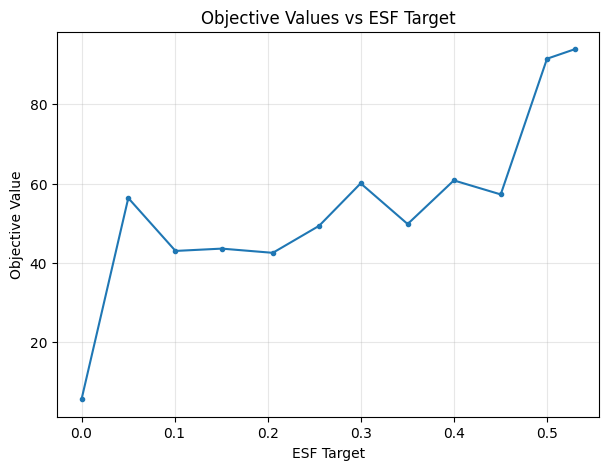

In [44]:
obj_list = pareto_cost

plt.figure(figsize=(7,5))
plt.plot(pareto_esf, obj_list, marker="o", ms=3)
plt.xlabel("ESF Target")
plt.ylabel("Objective Value")
# plt.xscale("log")
# plt.yscale("log")   # optional but often useful
plt.grid(True, alpha=0.3)
plt.title("Objective Values vs ESF Target")
plt.show()

## Regression

In [45]:
def build_regression_dataset(results):
    """
    Extract X (design vectors) and y (esf_sm) from results.
    """
    X = np.vstack([r["design_vector"] for r in results])   # shape: (n_samples, n_vars)
    y = np.array([r["esf_sm"] for r in results])           # shape: (n_samples,)
    return X, y

In [46]:
def fit_polynomial_esf_model(results, degree=2):
    """
    Polynomial regression: esf_sm ≈ f(d) with given degree.
    """
    X, y = build_regression_dataset(results)

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression(fit_intercept=False))
    ])
    model.fit(X, y)

    return model

In [47]:
def plot_actual_vs_predicted_poly(model, X, y, title_prefix="Polynomial regression"):
    # Predictions
    y_pred = model.predict(X)

    # Metrics (optional but useful)
    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y, y_pred, alpha=0.5, edgecolor="k")
    plt.xlabel("Actual esf_sm")
    plt.ylabel("Predicted esf_sm")

    title = f"{title_prefix}\nR²={r2:.3f}, RMSE={rmse:.3e}"
    plt.title(title)

    # 45-degree line
    min_v = min(y.min(), y_pred.min())
    max_v = max(y.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)

    plt.axis("equal")
    plt.tight_layout()
    plt.show()

In [105]:
reg_degree = 4

In [106]:
poly_model = fit_polynomial_esf_model(load_MC_results, degree=reg_degree)

In [107]:
poly = poly_model.named_steps["poly"]
lin = poly_model.named_steps["linreg"]

In [108]:
feature_names = poly.get_feature_names_out()
feature_names

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2', 'x0^3', 'x0^2 x1', 'x0^2 x2', 'x0 x1^2', 'x0 x1 x2',
       'x0 x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3', 'x0^4', 'x0^3 x1',
       'x0^3 x2', 'x0^2 x1^2', 'x0^2 x1 x2', 'x0^2 x2^2', 'x0 x1^3',
       'x0 x1^2 x2', 'x0 x1 x2^2', 'x0 x2^3', 'x1^4', 'x1^3 x2',
       'x1^2 x2^2', 'x1 x2^3', 'x2^4'], dtype=object)

In [109]:
for name, coef in zip(feature_names, lin.coef_):
    print(f"{name}: {coef}")
print("Intercept:", lin.intercept_)

x0: 0.01698057548743133
x1: 0.025639129438756056
x2: -0.09738611450739539
x0^2: -0.007136724826496005
x0 x1: -0.023128156564595412
x0 x2: 0.029705553515927383
x1^2: -0.008393842174183052
x1 x2: 0.027132800137740495
x2^2: 0.004091310597867876
x0^3: 0.0014411796584663794
x0^2 x1: 0.0018198681057232937
x0^2 x2: -0.004118461207249425
x0 x1^2: 0.002264528633440092
x0 x1 x2: 0.005639225841410913
x0 x2^2: -0.0030205278966942885
x1^3: 0.0013785400253650182
x1^2 x2: -0.004156254506299479
x1 x2^2: -0.0026144724183445687
x2^3: 0.0024546732565657726
x0^4: -8.150526682607947e-05
x0^3 x1: -0.00011524076681226744
x0^3 x2: 0.000138468714450459
x0^2 x1^2: 0.00013744136302940168
x0^2 x1 x2: -0.00022373868124017329
x0^2 x2^2: 0.0002529582529246175
x0 x1^3: -0.00017519112099175608
x0 x1^2 x2: -0.00018696597176516466
x0 x1 x2^2: -0.0002209222849023781
x0 x2^3: 2.990125745080334e-05
x1^4: -6.329937757254966e-05
x1^3 x2: 0.00014403619316120874
x1^2 x2^2: 0.00024359527496828137
x1 x2^3: 1.6288700107271134e-05

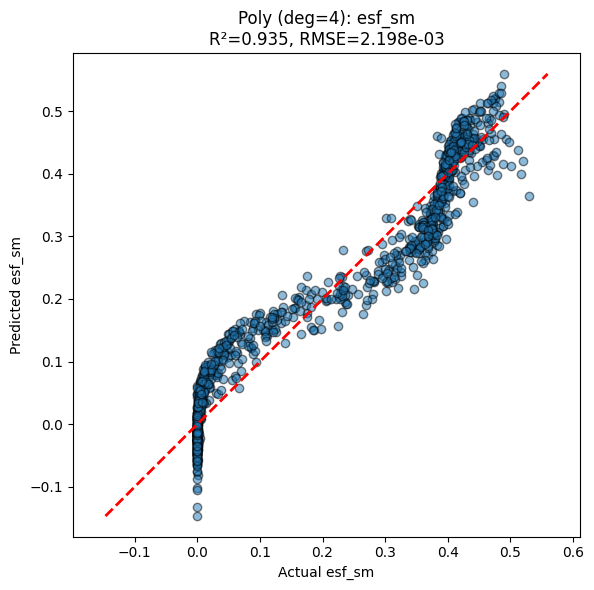

In [110]:
X, y = build_regression_dataset(load_MC_results)
plot_actual_vs_predicted_poly(poly_model, X, y, title_prefix=f"Poly (deg={reg_degree}): esf_sm")

## Model

In [111]:
def feature_to_expr(name, d_vars):
    """
    Convert a PolynomialFeatures feature name to a Gurobi expression
    in variables d_vars (tupledict or list of decision variables).
    Supports feature names like: 'x0', 'x1^2', 'x0 x1', 'x0^2 x2', etc.
    """
    # Single variable, maybe with power
    if "^" in name and " " not in name:
        base, pow_str = name.split("^")
        idx = int(base[1:])  # 'x0' -> 0
        power = int(pow_str)
        expr = d_vars[idx]
        for _ in range(power - 1):
            expr = expr * d_vars[idx]  # quadratic or higher
        return expr

    # Product of different variables, maybe repeated: 'x0 x1', 'x0^2 x2', etc.
    parts = name.split(" ")
    expr = 1.0
    for p in parts:
        if "^" in p:
            base, pow_str = p.split("^")
            idx = int(base[1:])
            power = int(pow_str)
            term = d_vars[idx]
            for _ in range(power - 1):
                term = term * d_vars[idx]
        else:
            idx = int(p[1:])
            term = d_vars[idx]
        expr = expr * term
    return expr

In [112]:
def create_gurobi_model(esf_t=0.0):
    m = gp.Model('ESF_design')
    d = m.addVars(
        len(d_bounds),
            lb=[b[0] for b in d_bounds],
            ub=[b[1] for b in d_bounds],
            name="d"
        )
    esf = m.addVar(lb=0, name="ESF")
    m.update()
    esf_target_con = m.addConstr(esf >= esf_t, name="esf_target")
    
    esf_expr = lin.intercept_

    for name, coef in zip(feature_names, lin.coef_):
        if abs(coef) < 1e-12:
            continue  # skip numerically zero coeffs
        term_expr = feature_to_expr(name, d)
        esf_expr += coef * term_expr
    
    m.update()
    
    m.addConstr(esf == esf_expr, name="esf_expr")
    m.update()

    obj_coeffs = [2, 3, 5]
    m.setObjective(gp.quicksum(obj_coeffs[j] * d[j] for j in d), GRB.MINIMIZE)
    m.update()
    
    return m, d, esf

In [113]:
grb_model, d_vars, ESF = create_gurobi_model(esf_t=0.2)

In [114]:
grb_model.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 4 columns and 1 nonzeros
Model fingerprint: 0x631a2d4f
Model has 1 general nonlinear constraint (71 nonlinear terms)
Variable types: 4 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+00, 5e+00]
  Bounds range     [1e+01, 1e+01]
  RHS range        [2e-01, 2e-01]
Presolve model has 1 nlconstr
Added 59 variables to disaggregate expressions.
Presolve removed 1 rows and 0 columns
Presolve time: 0.00s
Presolved: 147 rows, 64 columns, 321 nonzeros
Presolved model has 31 bilinear constraint(s)

Solving non-convex MIQCP

Variable types: 64 continuous, 0 integer (0 binary)
Found heuristic solution: objective 40.0126160

Root relaxation: objective 8.837634e-01, 24 iterations, 0.00 seconds (0.00 work units)

    Nodes  

In [115]:
for j in d_vars:
    print(f"d[{j}] = {d_vars[j].X}")

d[0] = 8.870444144496135
d[1] = 7.423909236983724
d[2] = 0.0


In [116]:
ESF.X

0.2

In [117]:
grb_model.ObjVal

40.01261599994344

In [82]:
design_vector = np.array([d_vars[j].X for j in d_vars])

In [83]:
design_vector

array([10.        ,  1.45115535,  0.        ])

In [84]:
esf_sm, sm_esf_by_state = calculate_sm_esf(y_dict, load_prepared_data_by_state, design_vector.reshape(-1,1), s_level=smolyak_level)

All filtered solutions are None for state (0, 0, 0); skipping state
Skipping state (0, 0, 1) due to ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1 and the array at index 1 has size 3
All filtered solutions are None for state (0, 1, 0); skipping state
All filtered solutions are None for state (1, 0, 0); skipping state
Skipping state (0, 1, 1) due to ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1 and the array at index 1 has size 3
Skipping state (1, 0, 1) due to ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1 and the array at index 1 has size 3
Skipping state (1, 1, 0) due to ValueError: all the input array dimensions except for the concatenation axis must match exactly, but alo

In [74]:
esf_sm

0.0

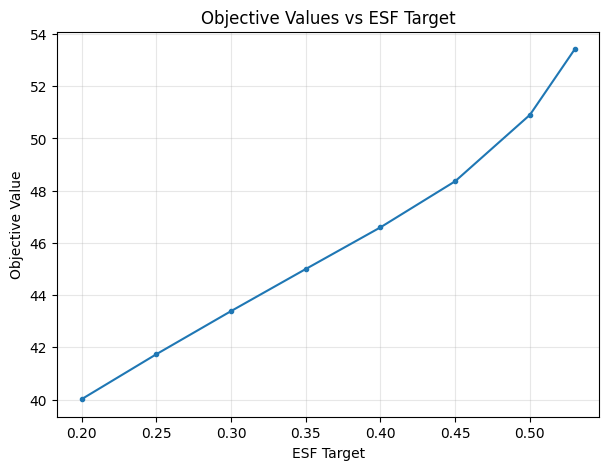

In [85]:
# # degree = 8
# eps_list = [0, 0.05, 0.1, 0.15, 0.2, ]
# obj_list = [0, 0.7488479164902785, 21.3631, 22.2942, 24.353466063747593]


# degree = 10
eps_list = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.53]
obj_list = [40.01261599994344, 41.734349505354245, 43.38638878065354, 44.997947020894344, 46.5949710535012, 48.35993256889622, 50.9020598445092, 53.41574712324851]

plt.figure(figsize=(7,5))
plt.plot(eps_list, obj_list, marker="o", ms=3)
plt.xlabel("ESF Target")
plt.ylabel("Objective Value")
# plt.xscale("log")
# plt.yscale("log")   # optional but often useful
plt.grid(True, alpha=0.3)
plt.title("Objective Values vs ESF Target")
plt.show()